# Segmentation

### importer les packages 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from numpy.lib import stride_tricks

### chargement d'image 

les dimension de l'image :  (576, 768)
l'hauteur de l'image :  576
largeur de l'image : 768


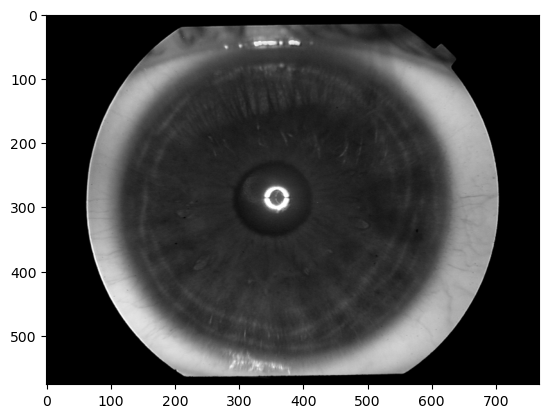

In [2]:
## 0 for reading the image in grayscale mode
img = cv.imread('001L_1.png',0)
dimensions = img.shape
print("les dimension de l'image : ", dimensions)
## largeur et hauteur de l'image
height = img.shape[0]
width = img.shape[1]
print("l'hauteur de l'image : ",height)
print("largeur de l'image :",width)
## afichage de l'image
plt.imshow(img, cmap=plt.get_cmap('gray'))

### Segmentation kmean : from scratch

In [3]:

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))
class KMeans():
    def __init__(self, K=5, max_iters=100, plot_steps=False):
        self.K = K
        self.max_iters = max_iters
        self.plot_steps = plot_steps
        # list of sample indices for each cluster
        self.clusters = [[] for _ in range(self.K)]
        # the centers (mean feature vector) for each cluster
        self.centroids = []
    def predict(self, X):
        self.X = X
        self.n_samples, self.n_features = X.shape
        
        # initialize 
        random_sample_idxs = np.random.choice(self.n_samples, self.K, replace=False)
        self.centroids = [self.X[idx] for idx in random_sample_idxs]
        # Optimize clusters
        for _ in range(self.max_iters):
            # Assign samples to closest centroids (create clusters)
            self.clusters = self._create_clusters(self.centroids)
            if self.plot_steps:
                self.plot()
            # Calculate new centroids from the clusters
            centroids_old = self.centroids
            self.centroids = self._get_centroids(self.clusters)
            
            # check if clusters have changed
            if self._is_converged(centroids_old, self.centroids):
                break
            if self.plot_steps:
                self.plot()
        # Classify samples as the index of their clusters
        return self._get_cluster_labels(self.clusters)
    def _get_cluster_labels(self, clusters):
        # each sample will get the label of the cluster it was assigned to
        labels = np.empty(self.n_samples)
        for cluster_idx, cluster in enumerate(clusters):
            for sample_index in cluster:
                labels[sample_index] = cluster_idx
        return labels
    def _create_clusters(self, centroids):
        # Assign the samples to the closest centroids to create clusters
        clusters = [[] for _ in range(self.K)]
        for idx, sample in enumerate(self.X):
            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx)
        return clusters
    def _closest_centroid(self, sample, centroids):
        # distance of the current sample to each centroid
        distances = [euclidean_distance(sample, point) for point in centroids]
        closest_index = np.argmin(distances)
        return closest_index
    def _get_centroids(self, clusters):
        # assign mean value of clusters to centroids
        centroids = np.zeros((self.K, self.n_features))
        for cluster_idx, cluster in enumerate(clusters):
            cluster_mean = np.mean(self.X[cluster], axis=0)
            centroids[cluster_idx] = cluster_mean
        return centroids
    def _is_converged(self, centroids_old, centroids):
        # distances between each old and new centroids, fol all centroids
        distances = [euclidean_distance(centroids_old[i], centroids[i]) for i in range(self.K)]
        return sum(distances) == 0
    def plot(self):
        fig, ax = plt.subplots(figsize=(12, 8))
        for i, index in enumerate(self.clusters):
            point = self.X[index].T
            ax.scatter(*point)
        for point in self.centroids:
            ax.scatter(*point, marker="x", color='black', linewidth=2)
        plt.show()
    def cent(self):
        return self.centroids

In [4]:
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

In [5]:
k = KMeans(K=3, max_iters=100)  
y_pred = k.predict(pixel_values) 

In [6]:
centers = np.uint8(k.cent())
y_pred = y_pred.astype(int)
np.unique(y_pred)

array([0, 1, 2])

In [7]:
labels = y_pred.flatten()
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(img.shape)

## Results :

Text(0.5, 1.0, 'Segmented Image when K = 3')

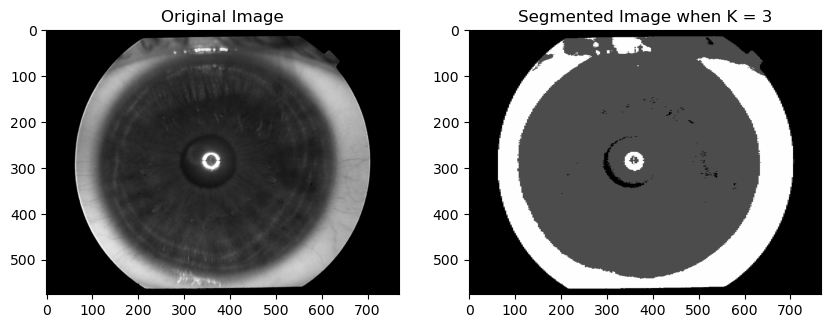

In [19]:
K=3
plt.figure(figsize=(10,10))
plt.subplot(1,2,1),plt.imshow(img, cmap=plt.get_cmap('gray'))
plt.title('Original Image')
plt.subplot(1,2,2),plt.imshow(segmented_image, cmap=plt.get_cmap('gray'))
plt.title('Segmented Image when K = %d' % K)

In [9]:
#### enregister l'images :
cv.imwrite('segmented.png',segmented_image)

True

## Segmentation kmean avec open cv :

In [20]:
pixel_vals = img.reshape((-1,3)) # reshape image
pixel_vals = np.float32(pixel_vals) # float type
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.85)

In [21]:
k = 3
retval, labels, centers = cv.kmeans(pixel_vals, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers) # convert data
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((img.shape)) # reshape

### Results

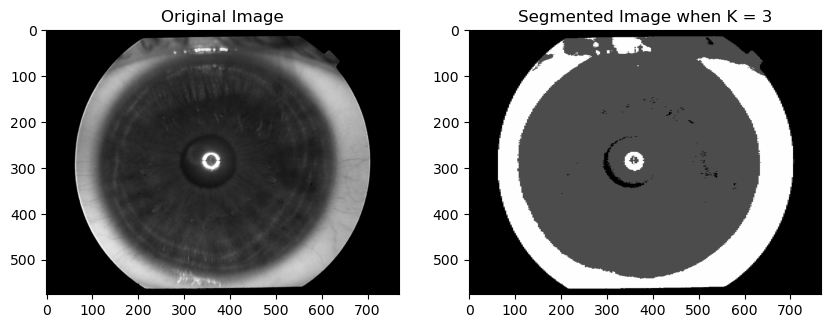

In [22]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1),plt.imshow(img, cmap=plt.get_cmap('gray'))
plt.title('Original Image')
plt.subplot(1,2,2),plt.imshow(segmented_image, cmap=plt.get_cmap('gray'))
plt.title('Segmented Image when K = %i' % k)
plt.show()